In [1]:
from src.MPOptoClass import *
from src.utils.gen_utils import *
from src.utils.filters import *
from src.helpers.experiment import *
from src.wiener_filter import *
from src.modeller import *
from src.MPRecordClass import *
from src.ReachingClass import *
from src.analysis import *
import scipy
import copy
import time
import mat73 
import pynapple as nap
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import colormaps
import random
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from itertools import permutations, compress, product




%load_ext autoreload 
%autoreload 2
%matplotlib widget

# sweep Regs SW bulk

In [4]:
output = pload('../picklejar/bulkSweepRegsSW_50post.pickle')
session_path = '../data/co/co9/co9_12122023'
session = MPOptoClass(session_path)

love


# inactivate CFA, predict RFA, top 20 PCs

In [147]:
session_lr2s = []
session_cr2s=[]

session_sw_lr2s = []
session_sw_cr2s=[]


session_ratios=[]
session_sw_ratios=[]
for this_session in output: 
    if this_session==0:
        continue
    if this_session[0][3] == 'cfa':
        continue
    run_lr2s=[]
    run_cr2s=[]
    run_ratios=[]

    run_sw_lr2s=[]
    run_sw_cr2s=[]
    run_sw_ratios=[]
    for run in this_session:
        
        h=run[0][0]
        run_lr2s.append(run[0][1])
        run_cr2s.append(run[0][2])
         
        h_sw=run[1][0]
        run_sw_lr2s.append(run[1][1])
        run_sw_cr2s.append(run[1][2])
        
        temp = session.weights_per_region(h, nlags=20, num_CFA=20)
        ratio = np.log10(temp[0]/temp[1])
        run_ratios.append(ratio)
        
        temp = session.weights_per_region(h_sw, nlags=20, num_CFA=20)
        ratio = np.log10(temp[0]/temp[1])
        run_sw_ratios.append(ratio)
        
    session_lr2s.append(run_lr2s)
    session_cr2s.append(run_cr2s)
    session_ratios.append(run_ratios)
    
    session_sw_lr2s.append(run_sw_lr2s)
    session_sw_cr2s.append(run_sw_cr2s)
    session_sw_ratios.append(run_sw_ratios)

    

# example sessions

/home/diya/anaconda3/envs/mp_opto/lib/python3.8/site-packages/ipywidgets/widgets/widget.py:501: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  super().__init__(**kwargs)


(-0.1, 0.5)

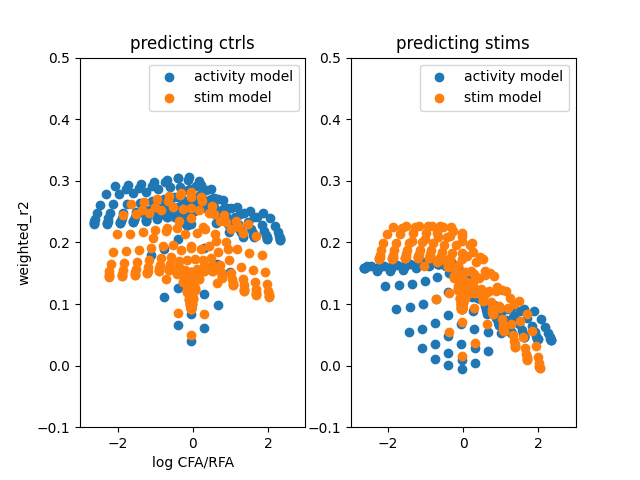

In [148]:
session_num = 0
fig, ax = plt.subplots(ncols=2)
ax[0].scatter(session_ratios[session_num], session_cr2s[session_num], color='tab:blue', label='activity model')
ax[0].scatter(session_sw_ratios[session_num], session_sw_cr2s[session_num], color='tab:orange', label='stim model')
ax[0].set_xlim(-3,3)
ax[0].set_ylim(-.1, .5)
ax[0].set_title('predicting ctrls')
ax[0].set_ylabel('weighted_r2')
ax[0].set_xlabel('log CFA/RFA')
ax[0].legend()

ax[1].scatter(session_ratios[session_num], session_lr2s[session_num], color='tab:blue', label='activity model')
ax[1].scatter(session_sw_ratios[session_num], session_sw_lr2s[session_num], color='tab:orange', label='stim model')
ax[1].set_title('predicting stims')
ax[1].set_xlim(-3,3)
ax[1].legend()
ax[1].set_ylim(-.1, .5)

/home/diya/anaconda3/envs/mp_opto/lib/python3.8/site-packages/ipywidgets/widgets/widget.py:501: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  super().__init__(**kwargs)


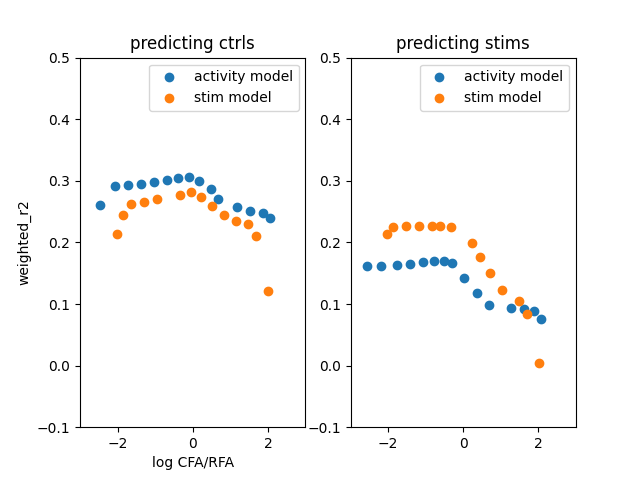

In [149]:
session_num = 0

ratio_keep, cr2_keep, edges = get_top_models(np.array(session_ratios[session_num]), np.array(session_cr2s[session_num]))
ratio_sw_keep, cr2_sw_keep, _ = get_top_models(np.array(session_sw_ratios[session_num]), np.array(session_sw_cr2s[session_num]), edges=edges)

ratio_lkeep, lr2_keep, edges = get_top_models(np.array(session_ratios[session_num]), np.array(session_lr2s[session_num]))
ratio_sw_lkeep, lr2_sw_keep, _ = get_top_models(np.array(session_sw_ratios[session_num]), np.array(session_sw_lr2s[session_num]), edges=edges)

fig, ax = plt.subplots(ncols=2)
ax[0].scatter(ratio_keep, cr2_keep, color='tab:blue', label='activity model')
ax[0].scatter(ratio_sw_keep, cr2_sw_keep, color='tab:orange', label='stim model')
ax[0].set_xlim(-3,3)
ax[0].set_ylim(-.1, .5)
ax[0].set_title('predicting ctrls')
ax[0].set_ylabel('weighted_r2')
ax[0].set_xlabel('log CFA/RFA')
ax[0].legend()

ax[1].scatter(ratio_lkeep, lr2_keep, color='tab:blue', label='activity model')
ax[1].scatter(ratio_sw_lkeep, lr2_sw_keep, color='tab:orange', label='stim model')
ax[1].set_xlim(-3,3)
ax[1].set_ylim(-.1, .5)
ax[1].set_title('predicting stims')
ax[1].legend()


/home/diya/anaconda3/envs/mp_opto/lib/python3.8/site-packages/ipywidgets/widgets/widget.py:501: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  super().__init__(**kwargs)


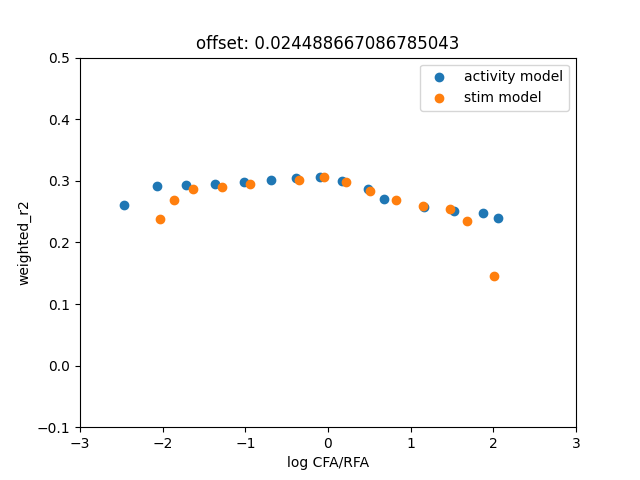

In [150]:
fig1, ax1 = plt.subplots()

#offset=0
offset = np.max(cr2_keep) - np.max(cr2_sw_keep)
ax1.scatter(ratio_keep, cr2_keep, label='activity model')
ax1.set_xlim(-3,3)
ax1.set_ylim(-.1, .5)
ax1.set_title('predicting ctrls')
ax1.set_ylabel('weighted_r2')
ax1.set_xlabel('log CFA/RFA')
ax1.scatter(ratio_sw_keep, cr2_sw_keep+offset, label='stim model')
ax1.set_title(f'offset: {offset}')
ax1.legend()

/home/diya/anaconda3/envs/mp_opto/lib/python3.8/site-packages/ipywidgets/widgets/widget.py:501: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  super().__init__(**kwargs)


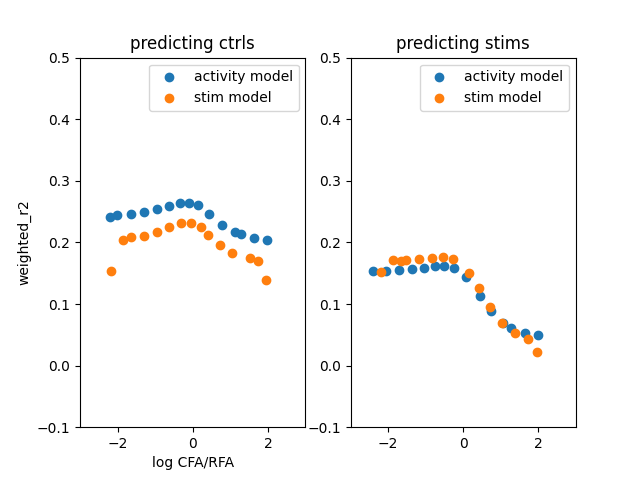

In [151]:
session_num = 0

ratio_keep, cr2_keep, edges = get_top_models(np.average(session_ratios, axis=0), np.average(session_cr2s, axis=0))
ratio_sw_keep, cr2_sw_keep, _ = get_top_models(np.average(session_sw_ratios, axis=0), np.average(session_sw_cr2s, axis=0), edges=edges)

ratio_lkeep, lr2_keep, edges = get_top_models(np.average(session_ratios, axis=0), np.average(session_lr2s, axis=0))
ratio_sw_lkeep, lr2_sw_keep, _ = get_top_models(np.average(session_sw_ratios, axis=0), np.average(session_sw_lr2s, axis=0), edges=edges)

fig, ax = plt.subplots(ncols=2)
ax[0].scatter(ratio_keep, cr2_keep, color='tab:blue', label='activity model')
ax[0].scatter(ratio_sw_keep, cr2_sw_keep, color='tab:orange', label='stim model')
ax[0].set_xlim(-3,3)
ax[0].set_ylim(-.1, .5)
ax[0].set_title('predicting ctrls')
ax[0].set_ylabel('weighted_r2')
ax[0].set_xlabel('log CFA/RFA')
ax[0].legend()

ax[1].scatter(ratio_lkeep, lr2_keep, color='tab:blue', label='activity model')
ax[1].scatter(ratio_sw_lkeep, lr2_sw_keep, color='tab:orange', label='stim model')
ax[1].set_xlim(-3,3)
ax[1].set_ylim(-.1, .5)
ax[1].set_title('predicting stims')
ax[1].legend()


/home/diya/anaconda3/envs/mp_opto/lib/python3.8/site-packages/ipywidgets/widgets/widget.py:501: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  super().__init__(**kwargs)


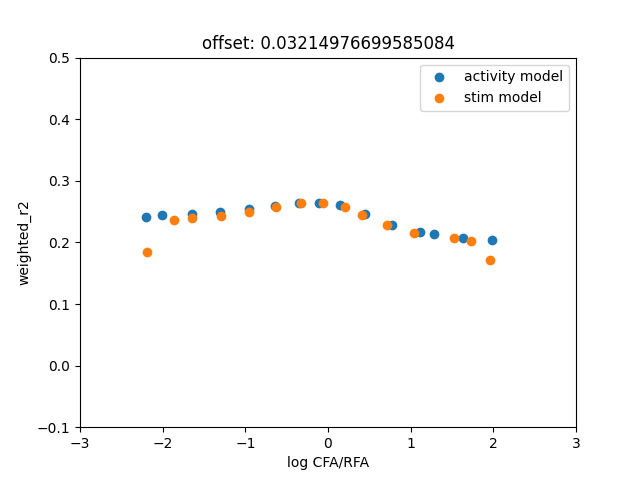

In [152]:
fig1, ax1 = plt.subplots()

#offset=0
offset = np.max(cr2_keep) - np.max(cr2_sw_keep)
ax1.scatter(ratio_keep, cr2_keep, label='activity model')
ax1.set_xlim(-3,3)
ax1.set_ylim(-.1, .5)
ax1.set_title('predicting ctrls')
ax1.set_ylabel('weighted_r2')
ax1.set_xlabel('log CFA/RFA')
ax1.scatter(ratio_sw_keep, cr2_sw_keep+offset, label='stim model')
ax1.set_title(f'offset: {offset}')
ax1.legend()

/home/diya/anaconda3/envs/mp_opto/lib/python3.8/site-packages/ipywidgets/widgets/widget.py:501: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  super().__init__(**kwargs)


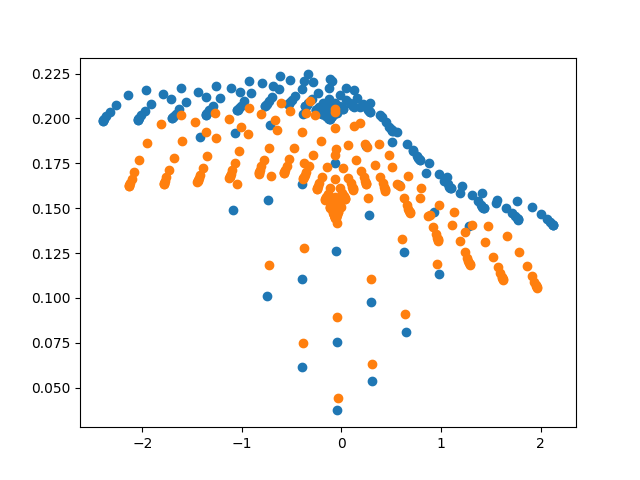

In [141]:
fig, ax = plt.subplots()
ax.scatter(np.average(session_ratios, axis=0), np.average(session_cr2s, axis=0))
ax.scatter(np.average(session_sw_ratios, axis=0), np.average(session_sw_cr2s, axis=0))

In [101]:
ratio_keep, cr2_keep, edges = get_top_models(np.average(session_ratios,axis=0), np.average(session_cr2s, axis=0))
ratio_sw_keep, cr2_sw_keep, _ = get_top_models(np.average(session_sw_ratios,axis=0), np.average(session_sw_cr2s, axis=0), edges=edges)

In [105]:
ratio_keep, cr2_keep, edges = get_top_models(np.array(session_ratios[2]), np.array(session_cr2s[2]))
ratio_sw_keep, cr2_sw_keep, _ = get_top_models(np.array(session_sw_ratios[2]), np.array(session_sw_cr2s[2]), edges=edges)

/home/diya/anaconda3/envs/mp_opto/lib/python3.8/site-packages/ipywidgets/widgets/widget.py:501: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  super().__init__(**kwargs)


Text(0.5, 1.0, 'offset: 0.02079297193297494')

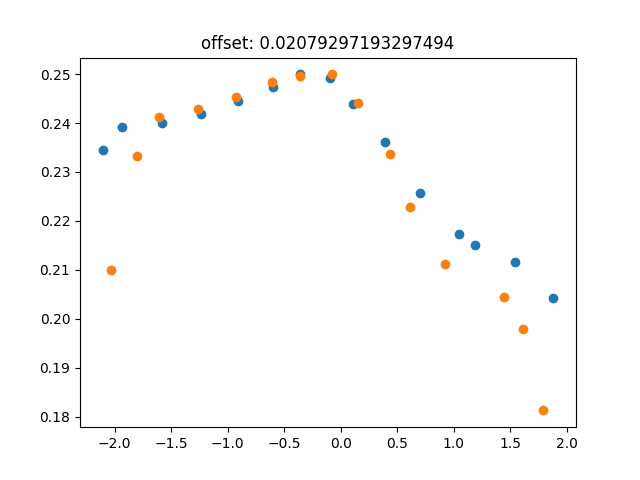

In [106]:
fig, ax = plt.subplots()

#offset=0
offset = np.max(cr2_keep) - np.max(cr2_sw_keep)
ax.scatter(ratio_keep, cr2_keep)
ax.scatter(ratio_sw_keep, cr2_sw_keep+offset)
ax.set_title(f'offset: {offset}')

# co6, predicting all CFA/RFA from all CFA/RFA climbing, first 20 PCs

In [ ]:
binsizes = [10,20,50]
num_PCs=20
nlags=10

r2_list = []
r2_cfa_list=[]

for binsize in binsizes:
    (X, Y), PCA_Objs = session.format_nlags_PCA(bounds = session.climbing_bounds, binsize=binsize, nlags=nlags, num_PCs=num_PCs)
    y,yhat, _ = wiener_kfolds(X, Y, c=(2,6))
    r2_list.append(weighted_r2(y,yhat, remove_lows=False))
    r2_cfa_list.append(weighted_r2(y[:,:num_PCs],yhat[:,:num_PCs]))
    
#50 ms bins, but with one history modele
nlags=1
r2_1lag_list = []

for binsize in binsizes:
    (X, Y), PCA_Objs = session.format_nlags_PCA(bounds = session.climbing_bounds, binsize=binsize, nlags=nlags, num_PCs=num_PCs)
    y,yhat, _ = wiener_kfolds(X, Y, c=(2,6))
    r2_1lag_list.append(weighted_r2(y,yhat))
    

/home/diya/anaconda3/envs/mp_opto/lib/python3.8/site-packages/ipywidgets/widgets/widget.py:501: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  super().__init__(**kwargs)


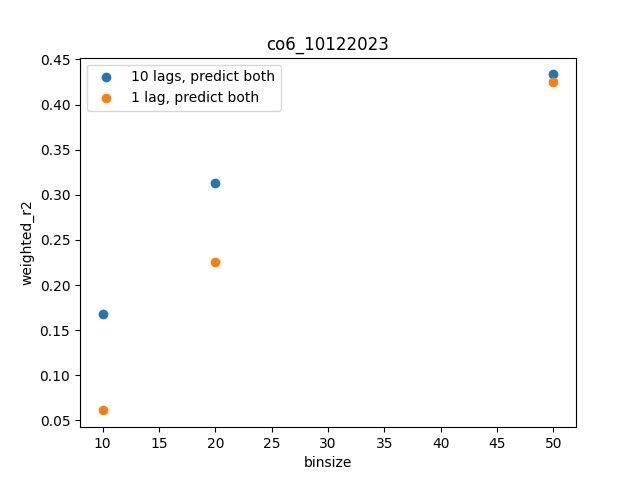

In [40]:
fig0, ax0 = plt.subplots()
ax0.set_xlabel('binsize')
ax0.set_ylabel('weighted_r2')
ax0.scatter(binsizes, r2_list, label='10 lags, predict both')
ax0.scatter(binsizes, r2_1lag_list, label='1 lag, predict both')
ax0.set_title('co6_10122023')
ax0.legend()

In [2]:
output = pload('../picklejar/bulkSweepRegs_50post.pickle')
session_path = '../data/co/co9/co9_12122023'
session = MPOptoClass(session_path)

love


In [4]:
session_lr2s = []
session_cr2s=[]
session_ratios=[]
for this_session in output: 
    if this_session==0:
        continue
    run_lr2s=[]
    run_cr2s=[]
    run_ratios=[]
    for run in this_session:
        
 

        h=run[0]
        run_lr2s.append(run[1])
        run_cr2s.append(run[2])
        temp = session.weights_per_region(h, nlags=20, num_CFA=20)
        ratio = np.log10(temp[0]/temp[1])
        run_ratios.append(ratio)
    session_lr2s.append(run_lr2s)
    session_cr2s.append(run_cr2s)
    session_ratios.append(run_ratios)

    

In [5]:
# lets sort based on ascending ratio
session_sort_ratios = []
session_sort_cr2s = []
for idx, ratio in enumerate(session_ratios):
    ratio = np.array(ratio)
    cr2 = np.array(session_cr2s[idx])
    sorty = np.argsort(ratio)
    session_sort_ratios.append(ratio[sorty])
    session_sort_cr2s.append(cr2[sorty])

/home/diya/anaconda3/envs/mp_opto/lib/python3.8/site-packages/ipywidgets/widgets/widget.py:501: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  super().__init__(**kwargs)


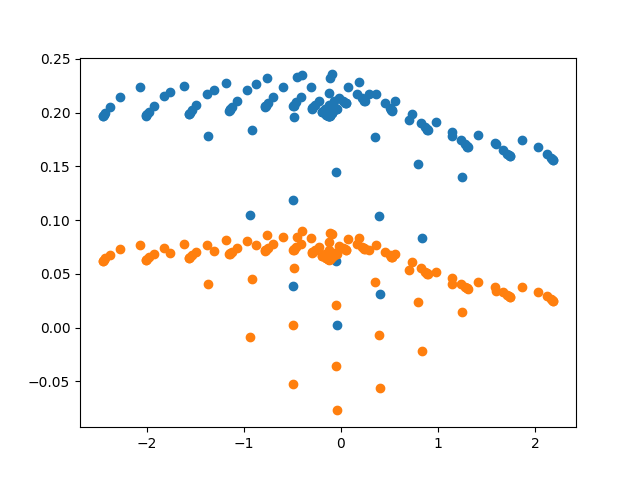

In [6]:
fig, ax = plt.subplots()
ax.scatter(np.average(session_ratios, axis=0), np.average(session_cr2s, axis=0))
ax.scatter(np.average(session_ratios, axis=0), np.average(session_lr2s, axis=0))

In [ ]:
# lets test sw with co12

In [142]:
session_path = '../data/co/co12/co12_02152024'
session = MPOptoClass(session_path)

love


In [163]:
nlags = 20
binsize=5
pre = nlags * binsize
post=50
num_PCs=20

laser_bounds = adjustBounds(session.laser['laser_bounds'], pre, post)
train_lasers, test_lasers = train_test_split(laser_bounds, train_size=0.8, random_state=1)
ctrl_bounds = adjustBounds(session.laser['ctrl_bounds'], pre, post)
omitLaserBounds = omitBoundInBounds(session.climbing_bounds, test_lasers)
omitLaserBounds = omitBoundInBounds(omitLaserBounds, ctrl_bounds)
(X, Y), X_PCs = session.format_nlags_PCA(omitLaserBounds, binsize=5, nlags=20, num_PCs=num_PCs)
(X_laser, Y_laser) = session.transformat_smooth(X_PCs, bounds=train_lasers, binsize=5, nlags=20, num_PCs=num_PCs, smooth_type='future')
(X_ctrl, Y_ctrl) = session.transformat_smooth(X_PCs, bounds=ctrl_bounds, binsize=5, nlags=20, num_PCs=num_PCs, smooth_type='future')

bounds too small for history
bounds too small for history
bounds too small for history
bounds too small for history
bounds too small for history
bounds too small for history
bounds too small for history


In [165]:
sw = session.getSWs(bigBound = omitLaserBounds, smallBound=train_lasers, sw_weight=25, binsize=5, nlags=20)

In [161]:
h = train_wiener_filter(X, Y[:,:num_PCs], c=(3,5), sweep='log')
Y_laser = Y_laser[:,:num_PCs]
yhat_laser = test_wiener_filter(X_laser, h)
Y_ctrl = Y_ctrl[:,:num_PCs]
yhat_ctrl = test_wiener_filter(X_ctrl, h)


None
best_c: 21544.346900318822


In [170]:
h = train_wiener_filter(X, Y[:,:num_PCs], c=(3,5), sw = sw, sweep='log')
Y_laser = Y_laser[:,:num_PCs]
yhat_laser = test_wiener_filter(X_laser, h)
Y_ctrl = Y_ctrl[:,:num_PCs]
yhat_ctrl = test_wiener_filter(X_ctrl, h)


[1. 1. 1. ... 1. 1. 1.]
best_c: 59948.42503189409


In [171]:
print(weighted_r2(Y_ctrl, yhat_ctrl))
print(weighted_r2(Y_laser, yhat_laser))

0.21506207833567237
0.26568067457476535


In [144]:
y, yhat, h = wiener_kfolds(X, Y[:,:20], c=(2,6), k=4, n_l2=4, sweep='log')

0it [00:00, ?it/s]

None
best_c: 2154.4346900318824


1it [00:01,  1.42s/it]

None
best_c: 46415.888336127726


2it [00:02,  1.40s/it]

None
best_c: 46415.888336127726


3it [00:04,  1.45s/it]

None
best_c: 46415.888336127726


4it [00:07,  1.88s/it]


In [145]:
print(weighted_r2(y,yhat))

0.12897827207725124


/home/diya/anaconda3/envs/mp_opto/lib/python3.8/site-packages/ipywidgets/widgets/widget.py:501: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  super().__init__(**kwargs)


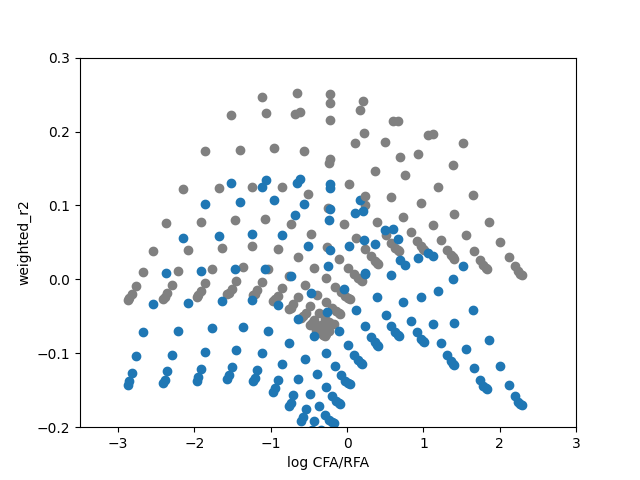

In [45]:
fig, ax = plt.subplots()
ratio_list = []
ratio2_list = []
h_list = []
laser_score_list = []
ctrl_score_list = []

raw_weights_list = []

tlaser_score_list =[]
tctrl_score_list = []
for idx, o in enumerate(output):
    h = o[0]
    h_stim = o[3]
    laser_score = o[1]
    ctrl_score = o[2]
    
    tlaser_score = o[4]
    tctrl_score = o[5]
    
    temp = session.weights_per_region(h)
    ratio = np.log10(temp[0]/temp[1])
    
    if min(temp) < .01:
        continue
    
    
    
    raw_weights_list.append(temp)
    
    temp2 = session.weights_per_region(h_stim)
    
    if min(temp2) < .01:
        continue
    ratio2 = np.log10(temp2[0]/temp2[1])
    
    
    ratio_list.append(ratio)
    ratio2_list.append(ratio2)
    h_list.append(h)
    laser_score_list.append(laser_score)
    ctrl_score_list.append(ctrl_score)
    tlaser_score_list.append(tlaser_score)
    tctrl_score_list.append(tctrl_score)
    
    #ax.scatter(ratio, o[1], color='blue')
    #ax.scatter(ratio, o[2], color='black')
    ax.scatter(ratio2, o[4], color='tab:blue')
    ax.scatter(ratio2, o[5], color='gray')
    ax.set_ylim(-0.2,0.3)
    ax.set_xlim(-3.5,3)
    ax.set_ylabel('weighted_r2')
    ax.set_xlabel('log CFA/RFA')
#ax.legend()

In [40]:
reg_terms = np.logspace(0,9,20)
reg_combos = list(product(reg_terms, reg_terms))
laser_score_list = np.array(laser_score_list)
ctrl_score_list = np.array(ctrl_score_list)
tlaser_score_list = np.array(tlaser_score_list)
tctrl_score_list = np.array(tctrl_score_list)
raw_weights_list = np.squeeze(np.array(raw_weights_list))
ratio_list = np.array(ratio_list)
ratio2_list = np.array(ratio2_list)
nada, bin_ratio_edges = np.histogram(ratio_list, bins=15)

laser_score_keep = []
ctrl_score_keep = []
tlaser_score_keep = []
tctrl_score_keep = []
ratio_keep = []
ratio2_keep = []
raw_weights = []

for i in range(bin_ratio_edges.size - 1):
    condition1 = ratio_list > bin_ratio_edges[i]
    condition2 = ratio_list < bin_ratio_edges[i+1]
    indices = np.argwhere(np.logical_and(condition1,condition2))
    
        keep = np.argmax(tctrl_score_list[indices]) 
        temp1 = tctrl_score_list[indices]
        temp2 = temp1[keep]
        tctrl_score_keep.append(temp2)
    
    temp1 = ratio2_list[indices]
    temp2 = temp1[keep]
    ratio2_keep.append(temp2)
    
    keep = np.argmax(ctrl_score_list[indices])
    temp1 = ctrl_score_list[indices]
    temp2 = temp1[keep]
    ctrl_score_keep.append(temp2) 
    
    temp1 = ratio_list[indices]
    temp2 = temp1[keep]
    ratio_keep.append(temp2)
    
        

    
    #indices = np.argwhere(np.logical_and(condition1,condition2))
    #keep = np.argmax(ctrl_score_list[indices])
    


/home/diya/anaconda3/envs/mp_opto/lib/python3.8/site-packages/ipywidgets/widgets/widget.py:501: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  super().__init__(**kwargs)


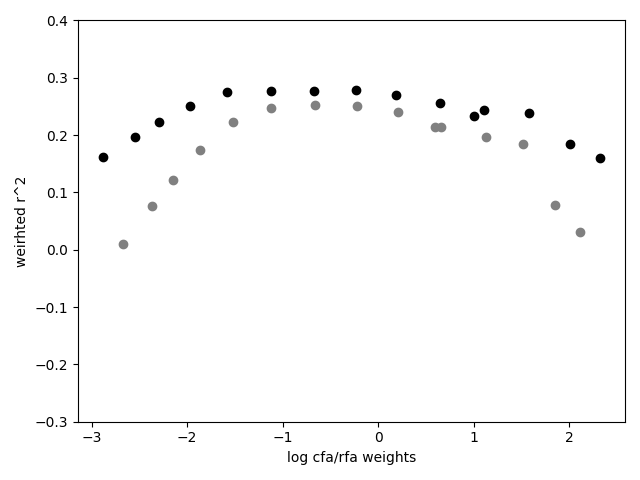

In [42]:
fig2, ax2 = plt.subplots()
ax2.scatter(ratio2_keep, tctrl_score_keep, c='gray', label='stim')
ax2.scatter(ratio_keep, ctrl_score_keep, c='black', label='ctrl')
#ax2[1].scatter(ratio2_keep, tlaser_score_keep, c='tab:blue', label='stim')
#ax2[1].scatter(ratio2_keep, tctrl_score_keep, c='black', label='ctrl')
#ax2[1].scatter(ratio_keep, laser_score_keep, c='tab:blue', label='activity model stim', alpha=0.2)
#ax2[1].scatter(ratio_keep, ctrl_score_keep, c='black', label='activity model ctrl', alpha=0.2)
ax2.set_ylabel('weirhted r^2')
#ax2[1].set_ylabel('weirhted r^2')
ax2.set_xlabel('log cfa/rfa weights')
#ax2.axhline(best_CFA_score, c='tab:blue', linestyle='--', label='CFA only r2 score')
#ax2.axhline(best_RFA_score, c= 'tab:red', linestyle='--', label='RFA only r2 score')
#ax2.legend()
#ax2[1].legend()
#ax2.set_title('co9 activity model \n (predicting RFA PCs, stim CFA, 10 ms bins, 10 lags)')
#ax2[1].set_title('co9, activity + stims model')


ax2.set_ylim(-.3, .4)
fig2.tight_layout()